<a href="https://colab.research.google.com/github/Fyaer/Data-Vis-Group-3-code/blob/main/project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

In [ ]:
teams = {'mens_swimming' : ['https://www.brooklyncollegeathletics.com/sports/mens-swimming-and-diving/roster/2022-23?view=2', 'https://athletics.baruch.cuny.edu/sports/mens-swimming-and-diving/roster?view=2' ,'https://csidolphins.com/sports/mens-swimming-and-diving/roster?view=2', 'https://lindenwoodlions.com/sports/mens-swimming-and-diving/roster?view=2', 'https://yorkathletics.com/sports/mens-swimming-and-diving/roster?view=2','https://mckbearcats.com/sports/mens-swimming-and-diving/roster?view=2','https://ramapoathletics.com/sports/mens-swimming-and-diving/roster?view=2', 'https://oneontaathletics.com/sports/mens-swimming-and-diving/roster?view=2', 'https://binghamtonbearcats.com/sports/mens-swimming-and-diving/roster/2021-22?view=2'] ,
         'mens_volleyball' : ['https://www.brooklyncollegeathletics.com/sports/mens-volleyball/roster?view=2', 'https://athletics.baruch.cuny.edu/sports/mens-volleyball/roster?view=2' , 'https://ccnyathletics.com/sports/mens-volleyball/roster?view=2' , 'https://lehmanathletics.com/sports/mens-volleyball/roster?view=2' , 'https://johnjayathletics.com/sports/mens-volleyball/roster?view=2' , 'https://mecathletics.com/sports/mens-volleyball/roster?view=2' , 'https://www.huntercollegeathletics.com/sports/mens-volleyball/roster?view=2', 'https://yorkathletics.com/sports/mens-volleyball/roster?view=2' , 'https://ballstatesports.com/sports/mens-volleyball/roster?view=2'] ,
         'womens_swimming' : ['https://csidolphins.com/sports/womens-swimming-and-diving/roster?view=2', 'https://queensknights.com/sports/womens-swimming-and-diving/roster?view=2', 'https://yorkathletics.com/sports/womens-swimming-and-diving/roster?view=2', 'https://athletics.baruch.cuny.edu/sports/womens-swimming-and-diving/roster/2021-22?view=2', 'https://www.brooklyncollegeathletics.com/sports/womens-swimming-and-diving/roster?view=2', 'https://lindenwoodlions.com/sports/womens-swimming-and-diving/roster?view=2', 'https://mckbearcats.com/sports/womens-swimming-and-diving/roster?view=2', 'https://ramapoathletics.com/sports/womens-swimming-and-diving/roster?view=2', 'https://keanathletics.com/sports/womens-swimming-and-diving/roster?view=2', 'https://oneontaathletics.com/sports/womens-swimming-and-diving/roster?view=2'] ,
         'womens_volleyball': ['https://bmccathletics.com/sports/womens-volleyball/roster?view=2', 'https://hostosathletics.com/sports/womens-volleyball/roster?view=2', 'https://bronxbroncos.com/sports/womens-volleyball/roster/2021?view=2', 'https://yorkathletics.com/sports/womens-volleyball/roster?view=2', 'https://queensknights.com/sports/womens-volleyball/roster?view=2', 'https://augustajags.com/sports/wvball/roster?view=2', 'https://flaglerathletics.com/sports/womens-volleyball/roster?view=2', 'https://pacersports.com/sports/womens-volleyball/roster?view=2', 'https://www.golhu.com/sports/womens-volleyball/roster?view=2']}


In [ ]:
#function to extract heights from urls
def process_data(team_type, urls):

 #Creating lists to store players names and heights
  names = []
  processed_heights = []

    #sending requests for all indvivdual urls
  for url in urls :

      #make a request to each individual url
      page = requests.get(url, verify=False)

    #Checking if request was successful
      if page.status_code == 200:

    # import raw html into BeautifulSoup
       soup = BeautifulSoup(page.content, 'html.parser')

    #extracting the tags that contains names
      name_tags = soup.find_all('td', class_ = 'sidearm-table-player-name')

    #extracting the tags that contains heights
      height_tags = soup.find_all('td', class_ = 'height')

    #iterating over both lists
      for name_tag, height_tag in zip(name_tags, height_tags):
         name = name_tag.get_text().strip()
         names.append(name)

      #Extracting the athletes hieghts

         height = float(height_tag['data-sort'])

         if height == 0.0:
           height = np.nan

       #inserting the height to the heights list
         processed_heights.append(height)

  df = pd.DataFrame({
      'Name': names,
      'Height':processed_heights
  })

  #replacing the nans in the dataframe with the average height
  mean_values = df['Height'].mean()
  df['Height'] = df['Height'].fillna(mean_values)

  #output the data to a csv file
  df.to_csv(f'{team_type}_heights.csv', index=False)

  return df, mean_values

In [ ]:
mens_volleyball_df, mens_volleyball_avg = process_data('mens_volleyball', teams['mens_volleyball'])


/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1100: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.brooklyncollegeathletics.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1100: InsecureRequestWarning: Unverified HTTPS request is being made to host 'athletics.baruch.cuny.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1100: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ccnyathletics.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.10/dist-package

In [ ]:
mens_volleyball_avg

72.45801526717557

In [ ]:
mens_swimming_df, mens_swimming_avg = process_data('mens_swimming', teams['mens_swimming'])



/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1100: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.brooklyncollegeathletics.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1100: InsecureRequestWarning: Unverified HTTPS request is being made to host 'athletics.baruch.cuny.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1100: InsecureRequestWarning: Unverified HTTPS request is being made to host 'csidolphins.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/

In [ ]:
mens_swimming_avg

71.3375

In [ ]:
womens_swimming_df, womens_swimming_avg = process_data('womens_swimming', teams['womens_swimming'])

/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1100: InsecureRequestWarning: Unverified HTTPS request is being made to host 'csidolphins.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1100: InsecureRequestWarning: Unverified HTTPS request is being made to host 'queensknights.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1100: InsecureRequestWarning: Unverified HTTPS request is being made to host 'yorkathletics.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.

In [ ]:
womens_swimming_avg

65.86046511627907

In [ ]:
womens_volleyball_df, womens_volleyball_avg = process_data('womens_volleyball', teams['womens_volleyball'])

/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1100: InsecureRequestWarning: Unverified HTTPS request is being made to host 'bmccathletics.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1100: InsecureRequestWarning: Unverified HTTPS request is being made to host 'hostosathletics.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1100: InsecureRequestWarning: Unverified HTTPS request is being made to host 'bronxbroncos.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/urllib3/connectionpo

In [ ]:
womens_volleyball_avg

67.59689922480621

In [ ]:
tallest_heights = mens_volleyball_df['Height'].drop_duplicates().nlargest(5)

In [ ]:
tallest_heights

,Height
129,82.0
130,81.0
70,79.0
96,78.0
11,77.0


In [ ]:
tallest_people = mens_volleyball_df['Height'].isin(tallest_heights)

In [ ]:
mens_volleyball_df[tallest_people]

,Name,Height
11,Jason Lin,77.0
30,Haoxin Hu,77.0
70,Kyle Barriffe-Johnson,79.0
89,Lucas George,77.0
93,Annes Deljanin,79.0
96,Jon Pflueger,78.0
98,Matisse Lee-Maarek,78.0
102,Austinson Cooke,77.0
114,Griffin Satterfield,79.0
115,Trevor Phillips,78.0


In [ ]:
tallest_heights = mens_swimming_df['Height'].drop_duplicates().nlargest(5)

In [ ]:
tallest_heights

,Height
83,79.0
155,77.0
8,76.0
2,75.0
0,74.0


In [ ]:
tallest_people = mens_swimming_df['Height'].isin(tallest_heights)

In [ ]:
tallest_heights = womens_swimming_df['Height'].drop_duplicates().nlargest(5)

In [ ]:
tallest_heights

,Height
78,75.0
66,73.0
40,72.0
51,71.0
58,70.0


In [ ]:
avg_heights = {
                'Team Category': ['Mens Volleyball Team', 'Mens Swim Team' , 'Womens Swim Team', 'Womens Volleyball Team'],
                'Avg Height': [mens_volleyball_avg, mens_swimming_avg, womens_volleyball_avg , womens_swimming_avg]
            }

avg_heights_df = pd.DataFrame(avg_heights)

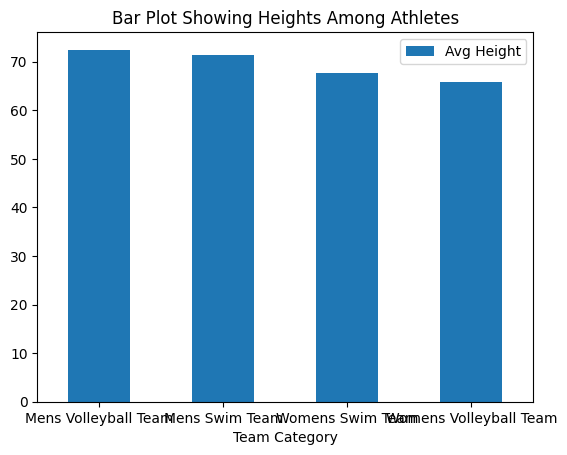

In [ ]:
avg_heights_df.plot.bar(x='Team Category', y = 'Avg Height', rot=0, title='Bar Plot Showing Heights Among Athletes')
plt.show()